# Import libraries and set configs

In [ ]:
import sys

sys.path.append("..")
sys.path.append("../..")

import ast
import json
import joblib
import numpy as np
import pandas as pd

import optuna
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb


class CFG:
    optimize = False
    # fold - train and validate data on TSS fold scheme
    # inference - train model on all available data and save it
    # test - test model in production on the new data
    train_test = "fold"
    # maximum number of simultaneously opened trades
    max_num_simult_trades = 100
    # significance level, that is used to conduct a t-test between 2 models
    optimize_alpha = 0.2
    n_repeats = 1
    n_folds = 8
    min_precision = 0.5


# Load the train data

In [ ]:
train_df = pd.read_pickle("data/train_df.pkl")

# all data for the last 90 days are test
test_date = train_df["time"].max() - pd.to_timedelta(90, unit="D")

profitable_hours_df = pd.read_csv("data/profitable_hours.csv")
latest = profitable_hours_df.iloc[-1]
buy_hours = ast.literal_eval(latest["profitable_buy_hours"])
sell_hours = ast.literal_eval(latest["profitable_sell_hours"])

buy_mask = (train_df["ttype"] == "buy") & (train_df["time"].dt.hour.isin(buy_hours))
sell_mask = (train_df["ttype"] == "sell") & (train_df["time"].dt.hour.isin(sell_hours))
train_df = train_df[buy_mask | sell_mask].reset_index(drop=True)

fi = pd.read_csv("model/feature_importance.csv")

# Train

### Load best parameters from Optuna dataframe

In [ ]:
from utils.optimization_utils import load_params_from_optuna

params = load_params_from_optuna(row_num=0)
params

### Load selected features

In [ ]:
from utils.feature_selection_utils import prepare_features

if CFG.optimize:
    feature_num = 100
    corr_thresh = 0.7

if "feature_num" in params:
    if not CFG.optimize:
        feature_num = params["feature_num"]
        corr_thresh = params["corr_thresh"]

    del params["feature_num"]
    del params["corr_thresh"]

fi = pd.read_csv("model/feature_importance.csv")
features, feature_dict = prepare_features(train_df, fi, feature_num, corr_thresh)

assert len(features) == len(set(features))

display(features, len(features))


### Functions for backtest

In [ ]:
slippage = 0.002
TP = CFG.cls_target_ratio_tp - slippage
SL = CFG.cls_target_ratio_sl + slippage


### Prepare model parameters

In [98]:
if "max_train_size" in params:
    max_train_size = params["max_train_size"]
    del params["max_train_size"]

# set high and low bound for model predictions
# p > high_bound -> 1, p < low_bound -> 0
if "high_bound" in params:
    high_bound = params["high_bound"]
    del params["high_bound"]
    del params["low_bound"]
low_bound = 0

# add object weights
if "sample_weight" in params:
    sample_weight = params["sample_weight"]
    del params["sample_weight"]

if sample_weight == "cos":
    train_df["weight"] = train_df["time"].astype(np.int64) / int(1e6)
    train_df["weight"] = (train_df["weight"].max() - train_df["weight"]) / (train_df["weight"].max() - train_df["weight"].min()) * np.pi / 2
    train_df["weight"] = np.cos(train_df["weight"])
    sample_weight = True
elif sample_weight == "linear":
    train_df["weight"] = train_df["time"].astype(np.int64) / int(1e6)
    train_df["weight"] = (train_df["weight"].max() - train_df["weight"]) / (train_df["weight"].max() - train_df["weight"].min())
    sample_weight = True


params["objective"] = "binary"
params["verbosity"] = -1
if params["boosting_type"] != "goss":
    params["subsample_freq"] = 1
else:
    params["subsample"] = None
    params["subsample_freq"] = None
params["importance_type"] = "gain"
params["metric"] = "average_precison"

### Train / optimize process

In [ ]:
from utils.optimization_utils import make_objective
from utils.model_train_utils import conf_ppv_npv_acc_score, model_train

with open("model/bybit_tickers.json", "r") as f:
    bybit_tickers = json.load(f)

if CFG.optimize:
    df_optuna_more_info = pd.DataFrame(columns=["result", "backtest_result", "oof_conf_score",
                                                "profit_objects", "oof_conf_obj_num", "scores"])
    df_optuna_more_info.to_csv("optuna/optuna_lgbm_info.csv", index=False)

    objective = make_objective(
        train_df, test_date, fi, bybit_tickers, TP, SL,
        n_folds=CFG.n_folds, optimize_alpha=CFG.optimize_alpha, min_precision=CFG.min_precision,
    )
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=750)

    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))

    df_optuna = study.trials_dataframe()
    df_optuna = df_optuna.sort_values("value", ascending=False)
    df_optuna.to_csv("optuna/optuna_lgbm.csv", index=False)

    display(df_optuna.head(10))
elif CFG.train_test == "fold":
    model, conf_scores, conf_object_nums, oof, val_idxs = model_train(
        train_df[train_df["time"] < test_date], features, params, sample_weight,
        n_folds=CFG.n_folds, low_bound=low_bound,
        high_bound=high_bound, train_test="fold",
        bybit_tickers=bybit_tickers,
        max_train_size=max_train_size, verbose=True,
    )
    y = train_df["target"][val_idxs]
    oof = oof[val_idxs]
    oof_conf_score, oof_conf_obj_num, oof_conf_obj_pct = conf_ppv_npv_acc_score(y, oof, low_bound, high_bound)

    print(80 * "=")
    print(f"Total confident object score: {oof_conf_score}\n"
          f"Total number of confident objects {oof_conf_obj_num}\n"
          f"Total number of profitable objects: {round((2 * oof_conf_score - 1) * oof_conf_obj_num)}")

    scores = [conf_object_num * (conf_score - CFG.min_precision) * 100 for conf_object_num, conf_score in zip(conf_object_nums, conf_scores)]
    print(f"Scores: {scores}")
elif CFG.train_test == "inference":
    model, _, _, _, _ = model_train(
        train_df, features, params, sample_weight,
        n_folds=8, low_bound=low_bound,
        high_bound=high_bound, train_test="inference",
        bybit_tickers=bybit_tickers,
        max_train_size=max_train_size, verbose=False,
    )
    joblib.dump(model, "model/lgbm.pkl")
    # save feature dictionary for further inference
    with open("model/features.json", "w") as f:
        json.dump(feature_dict, f)


### Visualize train results

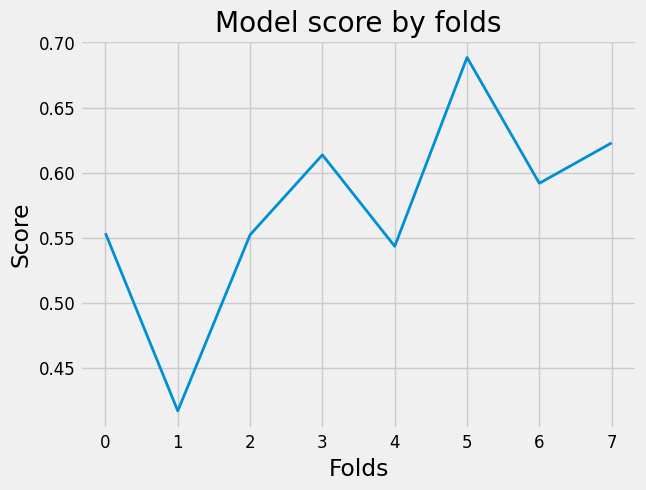

In [102]:
if not CFG.optimize and CFG.train_test == "fold":
    sns.lineplot(x=list(range(len(conf_scores))), y=conf_scores, linewidth=2)

    plt.title("Model score by folds")
    plt.xlabel("Folds")
    plt.xticks(fontsize=12)
    plt.ylabel("Score")
    plt.yticks(fontsize=12)

    plt.show()

### Display PR curve for fold predictions

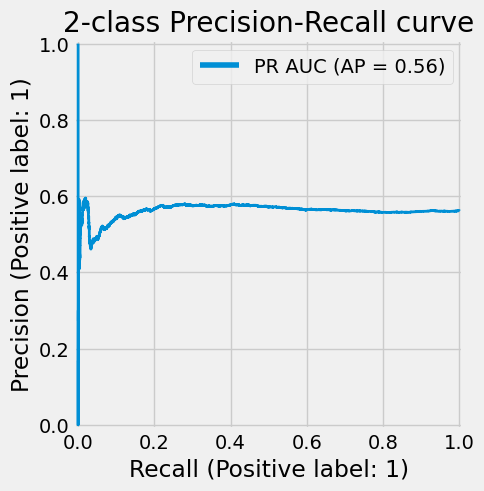

In [104]:
from sklearn.metrics import PrecisionRecallDisplay

if not CFG.optimize and CFG.train_test == "fold":
    disp = PrecisionRecallDisplay.from_predictions(
        y.values, oof, name="PR AUC"
    )
    plt.legend(loc="upper right")
    _ = disp.ax_.set_title("2-class Precision-Recall curve")
    disp.ax_.lines[0].set_linewidth(2)

# vol 1e6 AP=0.61

### Find the best threshold for fold predictions

ic| bound: np.float64(0.41)
    score: 0.56039
    obj_num: 8039
    obj_pct: 0.99
    obj_profit: 971
ic| bound: np.float64(0.411)
    score: 0.56041
    obj_num: 8037
    obj_pct: 0.99
    obj_profit: 971
ic| bound: np.float64(0.412)
    score: 0.5602
    obj_num: 8031
    obj_pct: 0.99
    obj_profit: 967
ic| bound: np.float64(0.413)
    score: 0.56023
    obj_num: 8027
    obj_pct: 0.99
    obj_profit: 967
ic| bound: np.float64(0.414)
    score: 0.56018
    obj_num: 8026
    obj_pct: 0.99
    obj_profit: 966
ic| bound: np.float64(0.415)
    score: 0.56014
    obj_num: 8023
    obj_pct: 0.99
    obj_profit: 965
ic| bound: np.float64(0.416)
    score: 0.56008
    obj_num: 8022
    obj_pct: 0.99
    obj_profit: 964
ic| bound: np.float64(0.417)
    score: 0.5602
    obj_num: 8015
    obj_pct: 0.99
    obj_profit: 965
ic| bound: np.float64(0.418)
    score: 0.56016
    obj_num: 8003
    obj_pct: 0.99
    obj_profit: 963
ic| bound: np.float64(0.419)
    score: 0.5603
    obj_num: 7994
  

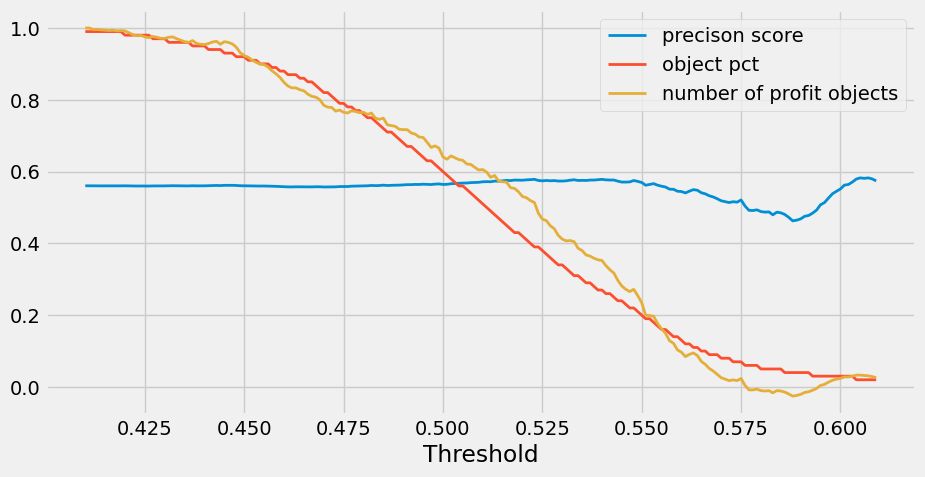

In [105]:
from icecream import ic

if not CFG.optimize and CFG.train_test == "fold":
    figsize = (10, 5)
    plt.figure(figsize=figsize)
    
    score_list = list()
    obj_num_list = list()
    obj_pct_list = list()
    obj_profit_list = list()
    max_obj_profit = 0
    for hb in np.arange(0.41, 0.61, 0.001):
        score, obj_num, obj_pct = conf_ppv_npv_acc_score(y.reset_index(drop=True), oof, 0, hb)
        if score == 0:
            obj_num = 0
            obj_pct = 0
        bound, score, obj_num, obj_pct = round(hb, 4), round(score, 5), round(obj_num, 2), round(obj_pct, 2)
        obj_profit = round((2 * score - 1) * obj_num)
        score_list.append(score)
        obj_num_list.append(obj_num)
        obj_pct_list.append(obj_pct)
        obj_profit_list.append(obj_profit)
        max_obj_profit = max(max_obj_profit, obj_profit)
        ic(bound, score, obj_num, obj_pct, obj_profit)

    obj_profit_list = [o / max_obj_profit for o in obj_profit_list]
    line1 = plt.plot(np.arange(0.41, 0.61, 0.001), score_list, label="precison score", linewidth=2)
    line2 = plt.plot(np.arange(0.41, 0.61, 0.001), obj_pct_list, label="object pct", linewidth=2)
    line3 = plt.plot(np.arange(0.41, 0.61, 0.001), obj_profit_list, label="number of profit objects", linewidth=2)
    
    plt.legend()
    plt.xlabel("Threshold")
    plt.show()

### Model feature importance

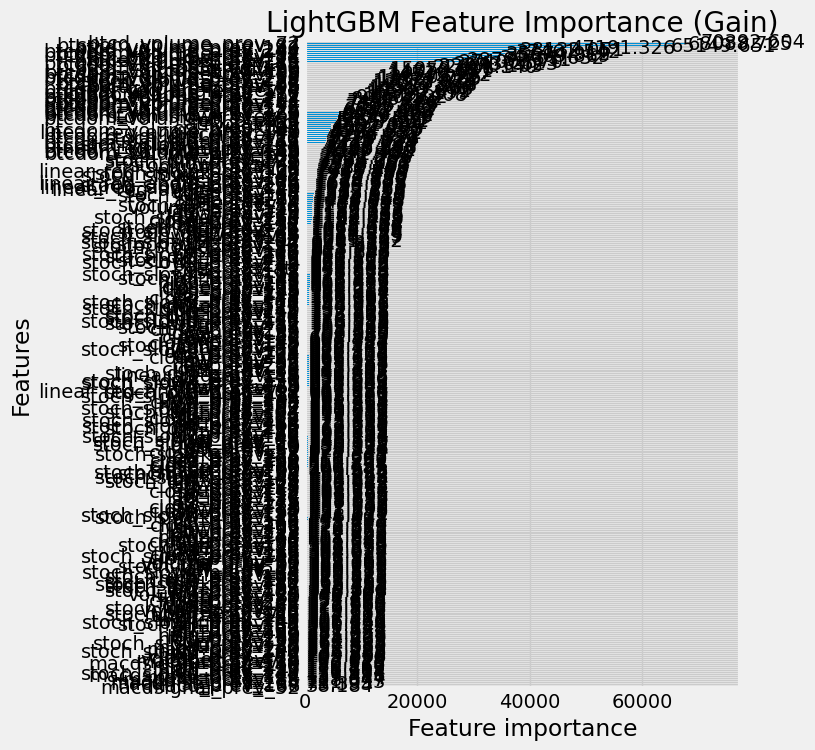

In [106]:
if not CFG.optimize and CFG.train_test == "fold":
    lgb.plot_importance(model, importance_type="gain", figsize=(5, 8), title="LightGBM Feature Importance (Gain)")
    plt.show()

# Error analysis

### Distribution of model pseudo-residuals

In [ ]:
from utils.model_test_utils import logloss

if not CFG.optimize and CFG.train_test == "fold":
    residual_df = train_df.loc[val_idxs, ["pred", "target"]]
    residual_df["pred"] = oof.ravel()
    y_true = residual_df["target"].values
    y_pred = residual_df["pred"].values
    residuals = -logloss(y_true, y_pred)
    residual_df["residuals"] = residuals

    sns.displot(np.log1p(residuals), bins=100)

    plt.xlabel("Model prediction residuals")
    plt.xticks(fontsize=10)
    plt.ylabel("Number of predictions")
    plt.yticks(fontsize=10)


### Pseudo-residuals vs Predictions plot

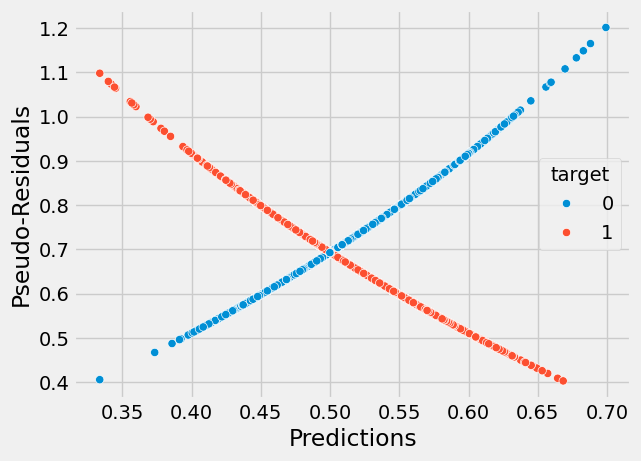

In [108]:
if not CFG.optimize and CFG.train_test == "fold":
    sns.scatterplot(residual_df, x="pred", y="residuals", hue="target")
    plt.xlabel("Predictions")
    plt.ylabel("Pseudo-Residuals");

### Residual stat tests

In [ ]:
from utils.stat_tests import test_normality, test_unbiased, test_homoscedasticity

if not CFG.optimize and CFG.train_test == "fold":
    display(test_normality(y_true, y_pred, alpha=0.05)) # p-value < 0.05 -> residuals distribution is not normal
    display(test_unbiased(y_true, y_pred, alpha=0.05)) # p-value < 0.05 -> residuals distribution is biased
    display(test_homoscedasticity(y_true, y_pred, bins=30, alpha=0.05)) # p-value < 0.05 -> residuals distribution is heteroscedastic

/home/alex/anaconda3/envs/sigbot/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8113.
  res = hypotest_fun_out(*samples, **kwds)


(np.float64(1.174264916632865e-79), np.True_)

(np.float64(7.303781859773753e-20), np.True_)

(np.float64(0.0), np.True_)

### Show worst predictions

In [110]:
if not CFG.optimize and CFG.train_test == "fold":
    worst_idxs = residual_df.query("pred >= @high_bound").sort_values("residuals", ascending=False).head(10).index
    worst_idxs_df = train_df.loc[worst_idxs, ["time", "ticker", "target", "ttype"]]
    worst_idxs_df["pred"] = residual_df.query("pred >= @high_bound").sort_values("residuals", ascending=False).head(10)["pred"]
    worst_idxs_df

### Show best predictions

In [111]:
if not CFG.optimize and CFG.train_test == "fold":
    best_idxs = residual_df.query("pred >= @high_bound").sort_values("residuals").head(10).index
    best_idxs_df = train_df.loc[best_idxs, ["time", "ticker", "target", "ttype"]]
    best_idxs_df["pred"] = residual_df.query("pred >= @high_bound").sort_values("residuals").head(10)["pred"]
    best_idxs_df

# Compare indicator / signal values for bot and optimizer

In [ ]:
# import fireducks.pandas as pd
# from signals.find_signal import SignalFactory

# ttype = "sell"
# ticker = "BADGERUSDT"
# month = 7
# day = 15
# hour = 23
# configs = ConfigFactory.factory(environ).configs

# x = pd.read_csv(f"../bot/ticker_dataframes/{ticker}_1h_{ttype}_{month}_{day}_{hour}.csv").drop(columns=["Unnamed: 0"]).reset_index(drop=True)
# y = pd.read_csv(f"../bot/ticker_dataframes/{ticker}_4h_{ttype}_{month}_{day}_{hour}.csv").drop(columns=["Unnamed: 0"]).reset_index(drop=True)

# # add Volume24
# vol24 = indicators.Volume24(ttype, configs)
# x = vol24.get_indicator(x, "", "1h", 0)
# # add Pattern
# pattern = indicators.Pattern(ttype, configs)
# x = pattern.get_indicator(x, "", "", 0)
# # add trend
# trend = indicators.Trend(ttype, configs)
# y = trend.get_indicator(y, "", "", 0)

# # cols = ["time", "open", "high", "low", "close", "volume", "rsi", "stoch_slowk", "stoch_slowd", "linear_reg", "linear_reg_angle", "macd", "macdsignal", "macdhist"]
# cols = ["time", "open", "high", "low", "close", "volume", "linear_reg", "linear_reg_angle", "high_max", "low_min", "volume_24"]

# higher_features = ["time_4h", "linear_reg", "linear_reg_angle", "macd", "macdhist",  "macd_dir", 
#                    "macdsignal", "macdsignal_dir"]
# x["time"] = pd.to_datetime(x["time"])
# y["time"] = pd.to_datetime(y["time"])
# y["time_4h"] = y["time"] + pd.to_timedelta(3, unit="h")
# x[["time"] + higher_features] = pd.merge(x[["time"]], y[higher_features], how="left", left_on="time", right_on="time_4h")

# # x = x.drop(columns=["time_4h"])
# # y = y.drop(columns=["time_4h"])
# x = x.ffill()
# x = x.reset_index(drop=True)

# # get Swing pattern
# pattern = SignalFactory().factory("Pattern", ttype, configs)
# pattern_points = pattern.find_signal(x)
# trend = SignalFactory().factory("Trend", ttype, configs)
# trend_points = trend.find_signal(x)
# idxs = np.where((pattern_points > 0) & (trend_points > 0))
# display(x.loc[idxs[0], cols])

# z = pd.read_pickle(f"data/tickers/{ticker}_1h.pkl")
# v = pd.read_pickle(f"data/tickers/{ticker}_4h.pkl")

# # add Volume24
# vol24 = indicators.Volume24(ttype, configs)
# z = vol24.get_indicator(z, "", "1h", 0)
# # add Pattern
# pattern = indicators.Pattern(ttype, configs)
# z = pattern.get_indicator(z, "", "", 0)
# # add Trend
# trend = indicators.Trend(ttype, configs)
# v = trend.get_indicator(v, "", "", 0)
# z.tail(48)

# v["time_4h"] = v["time"] + pd.to_timedelta(3, unit="h")
# z[["time"] + higher_features] = pd.merge(z[["time"]], y[higher_features], how="left", left_on="time", right_on="time_4h")

# z = z.drop(columns=["time_4h"])
# v = v.drop(columns=["time_4h"])
# z = z.ffill()
# z = z.reset_index(drop=True)

# # get Swing pattern
# pattern = SignalFactory().factory("Pattern", ttype, configs)
# pattern_points = pattern.find_signal(z)
# trend = SignalFactory().factory("Trend", ttype, configs)
# trend_points = trend.find_signal(z)
# idxs = np.where((pattern_points > 0) & (trend_points > 0))
# display(z.loc[idxs[0], cols])